# PointPillars (off-the-shelf KITTI) vs the keyframe 3D boxes

Visualizes `data/processed/detector_recall_zhu_report.json` from
`scripts/eval_detector_recall.py --detector pointpillars_zhu`.

This is the **supervisor-recommended detector** — `zhulf0804/PointPillars`, a clean
single-model implementation of PointPillars (Lang et al., CVPR 2019) — run **off-the-shelf**
on its KITTI weights (`pretrained/epoch_160.pth`), **no fine-tuning**. The question: does a
pretrained PointPillars transfer to ZOD pedestrians?

Scored on the **same 1,830 keyframe `location_3d` boxes** and the **same 2 m BEV match gate**
as the frustum and nuScenes-PointPillars runs, so all three are directly comparable. The
scan is motion-compensated to the keyframe instant (where the GT lives) before inference.

> Note: vanilla PointPillars uses a pillar encoder + 2D CNN — **no sparse 3D conv**, so this
> runs with no `spconv`/OpenPCDet stack.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = ROOT / "data" / "processed"
report = json.loads((PROC / "detector_recall_zhu_report.json").read_text())
cfg, overall = report["config"], report["overall"]

# Comparison runs (same GT / same gate), loaded if present.
def _load(name):
    p = PROC / name
    return json.loads(p.read_text()) if p.exists() else None
frustum = _load("frustum_poc_report.json")          # YOLO 2D + LiDAR depth
nusc    = _load("detector_recall_report.json")      # nuScenes PointPillars (OpenPCDet)

print("zhu cfg:", {k: cfg.get(k) for k in ("detector", "score_thresh", "intensity_scale",
                                           "match_dist_m", "keyframe_compensated")})
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

zhu cfg: {'detector': 'pointpillars_zhu', 'score_thresh': 0.1, 'intensity_scale': 0.00392156862745098, 'match_dist_m': 2.0, 'keyframe_compensated': True}


## 1. Three-way comparison (identical 1,830 GT, 2 m gate)

Off-the-shelf KITTI PointPillars vs off-the-shelf nuScenes PointPillars vs the frustum (YOLO 2D + LiDAR depth) approach.

PointPillars (KITTI, zhu)    recall=0.114  precision=0.229  (TP=208 FN=1622 FP=700  pred=908)
PointPillars (nuScenes)      recall=0.485  precision=0.085  (TP=888 FN=942 FP=9598  pred=10486)
Frustum (YOLO+LiDAR)         recall=0.585  precision=0.533  (TP=1071 FN=759 FP=938  pred=2009)


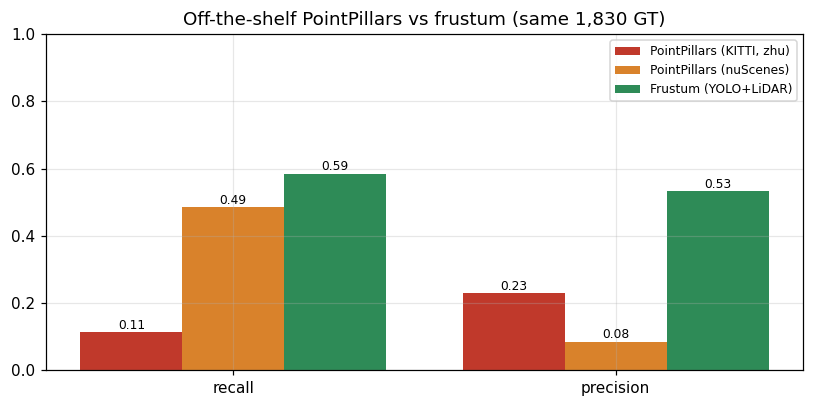

In [2]:
o = overall
rows = [("PointPillars (KITTI, zhu)", o, "#c0392b")]
if nusc:    rows.append(("PointPillars (nuScenes)", nusc["overall"], "#d9822b"))
if frustum: rows.append(("Frustum (YOLO+LiDAR)", frustum["overall"], "#2e8b57"))

for name, ov, _ in rows:
    print(f"{name:28} recall={ov['recall']:.3f}  precision={ov['precision']:.3f}  "
          f"(TP={ov['tp']} FN={ov['fn']} FP={ov['fp']}  pred={ov['n_pred']})")

fig, ax = plt.subplots(figsize=(7.5, 3.8))
x = np.arange(2); n = len(rows); w = 0.8 / n
for i, (name, ov, col) in enumerate(rows):
    off = (i - (n - 1) / 2) * w
    vals = [ov["recall"], ov["precision"]]
    ax.bar(x + off, vals, w, label=name, color=col)
    for xi, v in zip(x, vals):
        ax.text(xi + off, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(["recall", "precision"]); ax.set_ylim(0, 1.0)
ax.set_title("Off-the-shelf PointPillars vs frustum (same 1,830 GT)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2. Why so low? Range cap + domain gap

KITTI PointPillars is trained on a forward-only grid capped at ~69 m, on a 64-beam Velodyne
in Karlsruhe. ZOD pedestrians are often far and from a different sensor/scene. Two effects
stack up — and the **range** one is brutal: more than half the GT is beyond 40 m.

In [3]:
br = {b["bin"]: b for b in report["by_range_xy_m"]}
gt_far = sum(b["n_gt"] for k, b in br.items() if k == "[40,inf)")
gt_all = sum(b["n_gt"] for b in report["by_range_xy_m"])
tp_near = sum(round((b["recall"] or 0) * b["n_gt"]) for k, b in br.items() if k != "[40,inf)")
gt_near = gt_all - gt_far
print(f"GT beyond 40 m: {gt_far}/{gt_all} = {gt_far/gt_all:.0%}  (recall there = {br['[40,inf)']['recall']})")
print(f"recall restricted to <40 m: ~{tp_near}/{gt_near} = {tp_near/gt_near:.3f}")
print("-> even ignoring the range cap, the in-range recall is still far below nuScenes-PP (~0.72)")

GT beyond 40 m: 949/1830 = 52%  (recall there = 0.0084)
recall restricted to <40 m: ~200/881 = 0.227
-> even ignoring the range cap, the in-range recall is still far below nuScenes-PP (~0.72)


## 3. Recall by range and point sparsity (three-way)

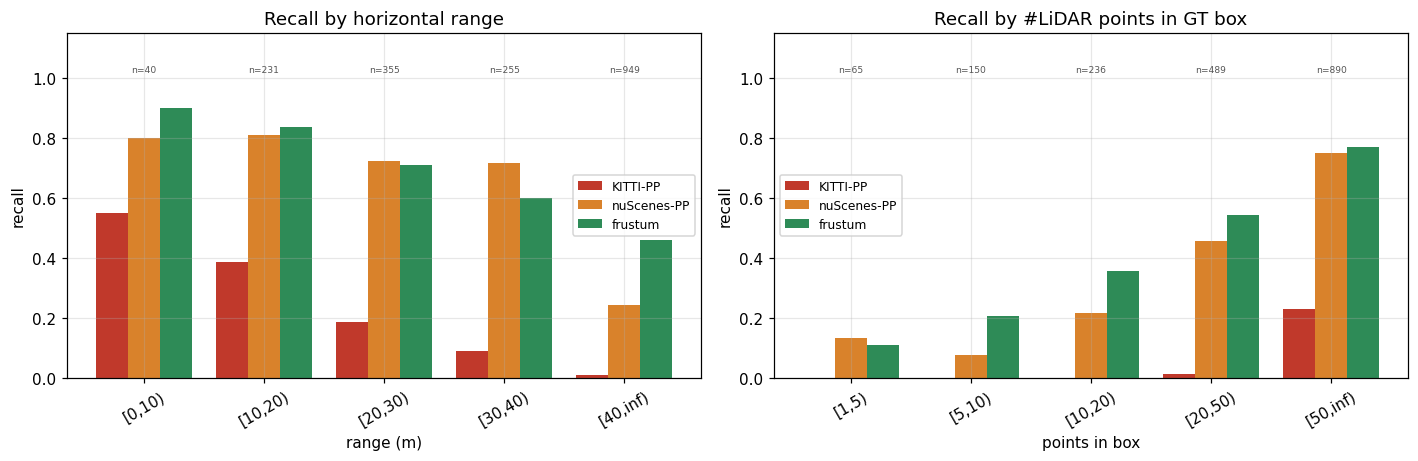

In [4]:
def overlay(ax, key, title, xlabel):
    base = report[key]
    labels = [b["bin"] for b in base]
    x = np.arange(len(labels))
    series = [("KITTI-PP", report, "#c0392b")]
    if nusc and key in nusc:       series.append(("nuScenes-PP", nusc, "#d9822b"))
    if frustum and key in frustum: series.append(("frustum", frustum, "#2e8b57"))
    w = 0.8 / len(series)
    for i, (name, rep, col) in enumerate(series):
        bins = rep[key]
        if len(bins) != len(labels):
            continue
        r = [b["recall"] if b["recall"] is not None else 0.0 for b in bins]
        off = (i - (len(series) - 1) / 2) * w
        ax.bar(x + off, r, w, label=name, color=col)
    for xi, b in zip(x, base):
        ax.text(xi, 1.02, f"n={b['n_gt']}", ha="center", fontsize=6, color="#555")
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30); ax.set_ylim(0, 1.15)
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel("recall"); ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
overlay(axes[0], "by_range_xy_m", "Recall by horizontal range", "range (m)")
overlay(axes[1], "by_lidar_points", "Recall by #LiDAR points in GT box", "points in box")
plt.tight_layout(); plt.show()

## 4. Visual: where PointPillars detects and where it misses

Left = keyframe image (gray = projected LiDAR) with GT pedestrian centres (green = detected,
red = missed) and PP detections (blue **+**). Right = BEV of the same, with PP detection
scores. First three rows are the best sequences; last three are failures with a pedestrian
within 30 m (so the miss is on-screen, not just beyond the range cap).

In [5]:
import sys
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "scripts"))

PP_OK = None
try:
    import torch  # noqa: F401
    from eval_detector_recall import make_pointpillars_zhu, match_greedy
    from dataset.keyframe import (keyframe_image_path, load_keyframe_pedestrians,
                                  nearest_lidar_scan, load_xyzi, parse_zod_ts,
                                  motion_compensate_to_keyframe, lidar_ts_from_filename)
    from utils.projection import load_calibration, project_lidar_to_image
    CKPT = Path.home() / "PointPillars" / "pretrained" / "epoch_160.pth"
    detector = make_pointpillars_zhu(CKPT, score_thresh=cfg.get("score_thresh", 0.1),
                                     intensity_scale=cfg.get("intensity_scale", 1/255))
    PP_OK = True
    print("PointPillars ready")
except Exception as e:
    print("unavailable -> skipping visual section:", repr(e)[:200])

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


PointPillars ready


visualizing (good then bad): ['000052', '000100', '000617', '000041', '000045', '000046']


/home/user20/miniforge3/envs/zod-iac/lib/python3.10/site-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3549.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


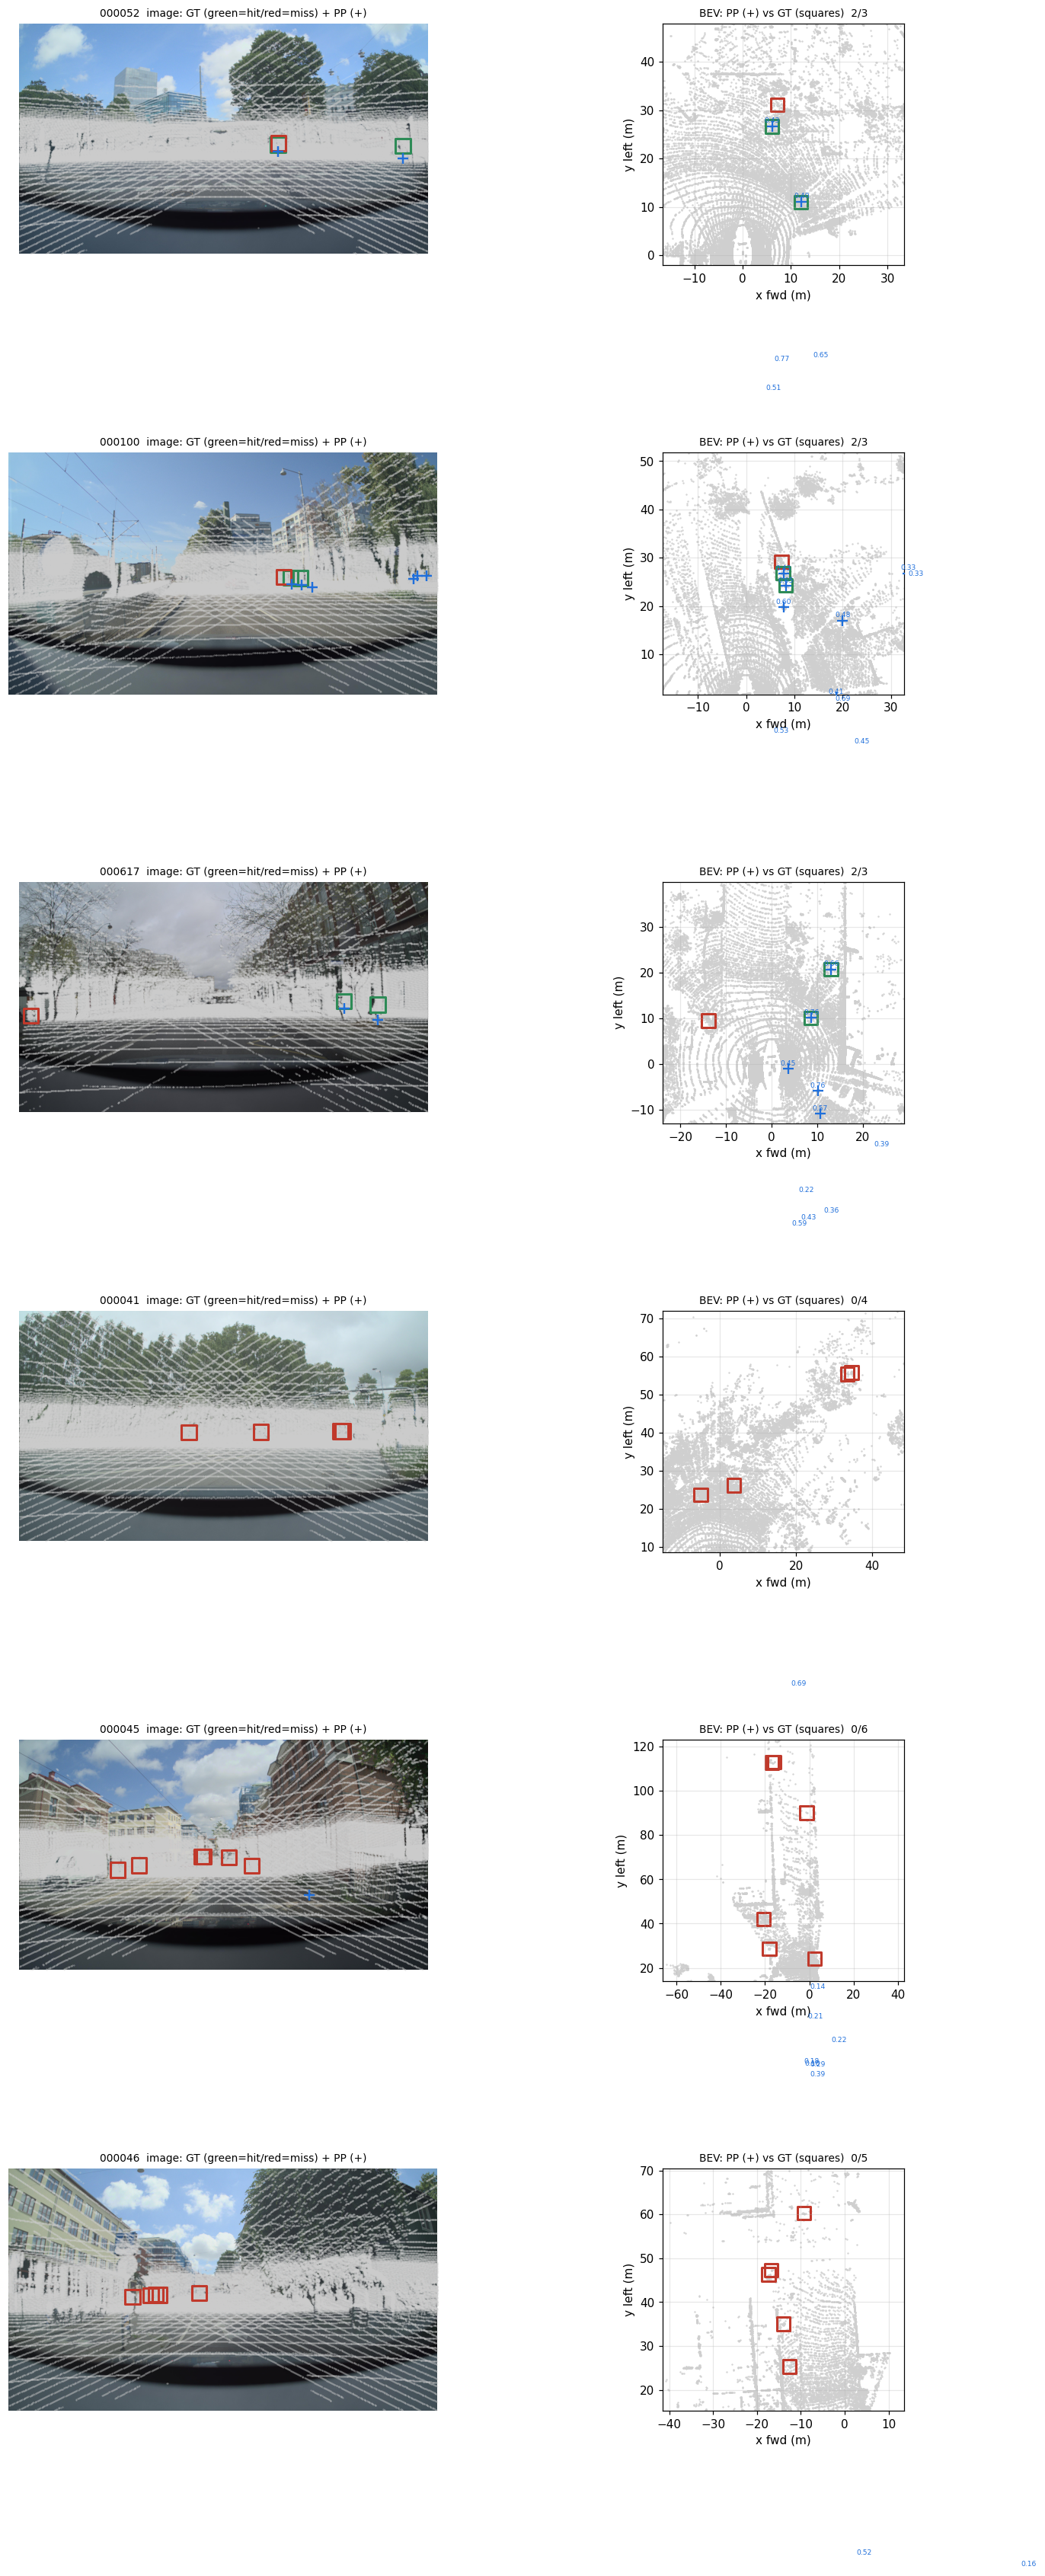

In [6]:
from matplotlib.patches import Rectangle  # noqa: F401
from PIL import Image

SEQ_DIR = ROOT / "data" / "raw" / "sequences"

def show_pair(ax_img, ax_bev, seq_id):
    sd = SEQ_DIR / seq_id
    img_path, _ = keyframe_image_path(sd)
    kts = parse_zod_ts(json.loads((sd / "info.json").read_text())["keyframe_time"])
    scan, _ = nearest_lidar_scan(sd / "lidar_velodyne", kts)
    calib = load_calibration(sd / "calibration.json")
    gts = load_keyframe_pedestrians(sd)
    xyzi = motion_compensate_to_keyframe(load_xyzi(scan), sd, lidar_ts_from_filename(scan.name), kts)
    pts = xyzi[:, :3]
    dets = detector(xyzi, gts)                       # same closure the report used
    matched = match_greedy(dets, gts, cfg["match_dist_m"])

    # ---- left: image ----
    uv, valid = project_lidar_to_image(pts, calib)
    ax_img.imshow(np.array(Image.open(img_path)))
    ax_img.scatter(uv[:, 0], uv[:, 1], s=0.2, c="#cfcfcf", alpha=0.4)
    if gts:
        guv, gvalid = project_lidar_to_image(np.array([g.center for g in gts]), calib)
        gh = np.array(matched)[gvalid]
        for sub, col in ((gh, "#2e8b57"), (~gh, "#c0392b")):
            ax_img.scatter(guv[sub, 0], guv[sub, 1], marker="s", facecolors="none",
                           edgecolors=col, s=160, lw=2)
    if dets:
        duv, dvalid = project_lidar_to_image(np.array([d.center for d in dets]), calib)
        ax_img.scatter(duv[:, 0], duv[:, 1], marker="+", c="#1f6fdb", s=90, lw=1.6)
    ax_img.set_title(f"{seq_id}  image: GT (green=hit/red=miss) + PP (+)", fontsize=9)
    ax_img.axis("off")

    # ---- right: BEV ----
    focus = [g.center[:2] for g in gts] or [d.center[:2] for d in dets] or [np.zeros(2)]
    C = np.asarray(focus, float); cx0, cy0 = C[:, 0].mean(), C[:, 1].mean()
    half = max(25.0, float(np.abs(C - [cx0, cy0]).max()) + 10.0)
    m = (np.abs(pts[:, 0] - cx0) <= half) & (np.abs(pts[:, 1] - cy0) <= half)
    p = pts[m]
    ax_bev.scatter(p[::3, 0], p[::3, 1], s=0.3, c="#cfcfcf")
    for g, hit in zip(gts, matched):
        col = "#2e8b57" if hit else "#c0392b"
        ax_bev.scatter(g.center[0], g.center[1], marker="s", facecolors="none",
                       edgecolors=col, s=130, lw=2)
    for d in dets:
        ax_bev.scatter(d.center[0], d.center[1], marker="+", c="#1f6fdb", s=80, zorder=5)
        ax_bev.text(d.center[0], d.center[1] + 0.7, f"{d.score:.2f}", fontsize=6,
                    ha="center", color="#1f6fdb")
    ax_bev.set_xlim(cx0 - half, cx0 + half); ax_bev.set_ylim(cy0 - half, cy0 + half)
    ax_bev.set_aspect("equal"); ax_bev.set_xlabel("x fwd (m)"); ax_bev.set_ylabel("y left (m)")
    ax_bev.set_title(f"BEV: PP (+) vs GT (squares)  {sum(matched)}/{len(gts)}", fontsize=9)

if PP_OK:
    def nearest_gt_range(sid):
        gs = load_keyframe_pedestrians(SEQ_DIR / sid)
        return min((g.range_xy for g in gs), default=1e9)
    scored = [s for s in report["per_sequence"] if s.get("recall") is not None and s["n_gt"] >= 3]
    good = sorted(scored, key=lambda s: -s["recall"])[:3]
    near = [s for s in scored if nearest_gt_range(s["seq_id"]) <= 30]
    bad = sorted(near, key=lambda s: s["recall"])[:3]
    seqs = [s["seq_id"] for s in good] + [s["seq_id"] for s in bad]
    print("visualizing (good then bad):", seqs)
    fig, axes = plt.subplots(len(seqs), 2, figsize=(15, 5.2 * len(seqs)),
                             gridspec_kw={"width_ratios": [2, 1]})
    axes = np.atleast_2d(axes)
    for i, sq in enumerate(seqs):
        show_pair(axes[i][0], axes[i][1], sq)
    plt.tight_layout(); plt.show()

**Conclusion.** Off-the-shelf PointPillars is **not** the detector for ZOD: KITTI weights
give recall ~0.11 (vs 0.49 for nuScenes weights and 0.59 for the frustum), collapsing to
near-zero beyond 40 m where >half the pedestrians are, and staying low even in-range. This is
a **transfer/domain-gap** result, not a refutation of PointPillars as a method — the next
step that would actually answer "is PP good enough for ZOD" is to **fine-tune it on the 1,776
keyframe boxes** and re-run this exact comparison.